# 4 Robot Version


Looks like tracking the determinant fails in all but the most contrived cases. We need to find a way that works with more.

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

## Vector Field

In [2]:
class VectorField:
    """Vector field with two counter-rotating vortices."""
    
    def __init__(self):
        self.vortex1_pos = np.array([-2, -1])
        self.vortex2_pos = np.array([2, -1])
        self.vortex3_pos = np.array([-1, 3])
        self.vortex4_pos = np.array([1, 3])
        self.source_pos = np.array([4, 0])


    # Double Vortex System
        
    # def evaluate(self, x, y):
    #     """Evaluate the vector field at position (x, y)."""
    #     # Left vortex (counterclockwise)
    #     x1, y1 = self.vortex1_pos
    #     vx1 = -(y - y1)
    #     vy1 = (x - x1)
        
    #     # Right vortex (clockwise)
    #     x2, y2 = self.vortex2_pos
    #     vx2 = (y - y2)
    #     vy2 = -(x - x2)

    #     # Combine with distance-based weighting
    #     d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
    #     d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
    #     w1 = 1.0 / (d1**2 + 0.1)
    #     w2 = 1.0 / (d2**2 + 0.1)
    #     vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
    #     vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
    #     return np.array([10*vx, 10*vy])



##  Four Vortex System



    # def evaluate(self, x, y):
    #     """Evaluate the vector field at position (x, y)."""
    #     epsilon = 0.1  # Regularization parameter to avoid singularities
        
    #     # Define vortex positions and strengths (positive = counterclockwise)
    #     vortices = [
    #         (self.vortex1_pos, 1.0),   # Counterclockwise
    #         (self.vortex2_pos, -1.0),  # Clockwise
    #         (self.vortex3_pos, 1.0),   # Counterclockwise
    #         (self.vortex4_pos, -1.0),  # Clockwise
    #     ]
        
    #     vx_total = 0
    #     vy_total = 0
        
    #     for (xi, yi), strength in vortices:
    #         dx = x - xi
    #         dy = y - yi
    #         r_squared = dx**2 + dy**2 + epsilon
            
    #         # Vortex velocity field: v = strength * (-dy, dx) / r²
    #         vx_total += strength * (-dy) / r_squared
    #         vy_total += strength * dx / r_squared
        
    #     # Scale factor for visualization
    #     scale = 1.0
    #     return np.array([scale * vx_total, scale * vy_total])



# Double Saddle System

    def evaluate(self, x, y):
        """Evaluate the two-saddle heteroclinic vector field at position (x, y)."""
        
        # Define saddle positions for heteroclinic orbit
        saddle1_pos = np.array([3, 3])  # Left saddle
        saddle2_pos = np.array([-3, -3])    # Right saddle
        
        # Saddle parameters
        strength1 = 1.0
        strength2 = 1.0
        rotation1 = np.pi/4   # 45 degrees
        rotation2 = -np.pi/4  # -45 degrees
        coupling = 0.0        # Controls interaction strength
        
        # Calculate saddle 1 contribution
        x1_centered = x - saddle1_pos[0]
        y1_centered = y - saddle1_pos[1]
        
        # Apply rotation1
        cos_rot1 = np.cos(rotation1)
        sin_rot1 = np.sin(rotation1)
        x1_rot = cos_rot1 * x1_centered - sin_rot1 * y1_centered
        y1_rot = sin_rot1 * x1_centered + cos_rot1 * y1_centered
        
        # Saddle equations
        u1_rot = strength1 * x1_rot
        v1_rot = -strength1 * y1_rot
        
        # Rotate back
        u1 = cos_rot1 * u1_rot + sin_rot1 * v1_rot
        v1 = -sin_rot1 * u1_rot + cos_rot1 * v1_rot
        
        # Calculate saddle 2 contribution
        x2_centered = x - saddle2_pos[0]
        y2_centered = y - saddle2_pos[1]
        
        # Apply rotation2
        cos_rot2 = np.cos(rotation2)
        sin_rot2 = np.sin(rotation2)
        x2_rot = cos_rot2 * x2_centered - sin_rot2 * y2_centered
        y2_rot = sin_rot2 * x2_centered + cos_rot2 * y2_centered
        
        # Saddle equations
        u2_rot = strength2 * x2_rot
        v2_rot = -strength2 * y2_rot
        
        # Rotate back
        u2 = cos_rot2 * u2_rot + sin_rot2 * v2_rot
        v2 = -sin_rot2 * u2_rot + cos_rot2 * v2_rot
        
        # Distance-based weighting for smooth blending
        d1 = np.sqrt((x - saddle1_pos[0])**2 + (y - saddle1_pos[1])**2) + 0.01
        d2 = np.sqrt((x - saddle2_pos[0])**2 + (y - saddle2_pos[1])**2) + 0.01
        
        # Inverse distance weighting
        w1 = 1.0 / (d1**2 + coupling)
        w2 = 1.0 / (d2**2 + coupling)
        
        # Combine the fields
        total_weight = w1 + w2
        u_combined = (u1 * w1 + u2 * w2) / total_weight
        v_combined = (v1 * w1 + v2 * w2) / total_weight
        
        # Scale factor for visualization
        scale = 1.0
        return np.array([scale * u_combined, scale * v_combined])


    # def evaluate(self, x, y):
    #     # Vanderpole? Looks weird. do not uses
    #     vx = x*(x**2 - 1)
    #     vy = -y       
    #     return np.array([vx, vy])
    
    def evaluate(self, x, y):
        # Dunno, but this works at first, then finds a stronger separatrix?

        vx = ((x)**2 - 4)
        vy = -2*x*y
        
        return np.array([vx, vy])

    # def evaluate(self, x, y):
    #     # moves from saddle to saddle, but not in the way I expect.

    #     vx = y
    #     vy = np.sin(x)

        
    #     return np.array([vx, vy])
    
    def jacobian_twosided(self, x, y, h=0.01):
        """Compute Jacobian using two-sided finite differences."""
        fx_plus, fy_plus = self.evaluate(x + h, y)
        fx_minus, fy_minus = self.evaluate(x - h, y)
        fx_yplus, fy_yplus = self.evaluate(x, y + h)
        fx_yminus, fy_yminus = self.evaluate(x, y - h)
        
        J = np.array([
            [(fx_plus - fx_minus) / (2*h), (fx_yplus - fx_yminus) / (2*h)],
            [(fy_plus - fy_minus) / (2*h), (fy_yplus - fy_yminus) / (2*h)]
        ])
        return J

## Robot Cluster


The default positions of the robots are:

        2     1   
        3     4

The angle between 0 is the perpendicular to the line 1,4

In [3]:
class RobotCluster4:
    """Cluster of 4 robots for vector field navigation."""
    
    def __init__(self, num_robots=4, formation_radius=0.2, init_mode=1, manual_offset=0):
        """
        Parameters:
        -----------
        init_mode : int
            1 - Square formation with manual angle offset
            2 - Square formation with random angle offset
            3 - Equilateral triangle + center with random angle offset
        manual_offset : float
            Manual angle offset for mode 1 (in radians)
        """
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        self.init_mode = init_mode
        self.positions = np.zeros((num_robots, 2))
        self.centroid = np.array([0.85, -0.4])
        self.vector_readings = np.zeros((num_robots, 2))
        
        # Initialize formation angle based on mode
        if init_mode == 1:                                              # Set to 1 for final code
            self.formation_angle = manual_offset + np.pi/4              # Hard coded here.
            self.rotation_enabled = False
        else:
            self.formation_angle = np.random.uniform(0, 2*np.pi)
            self.rotation_enabled = True
        
        self.angle_history = [self.formation_angle]
        self._update_robot_positions()
        
    def _update_robot_positions(self):
        """Update robot positions based on formation type."""
        if self.init_mode in [1, 2]:  # Square formation
            angles = np.linspace(0, 2*np.pi, 4, endpoint=False)
            angles = angles + self.formation_angle
            for i in range(4):
                self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        elif self.init_mode == 3:  # Triangle + center
            triangle_angles = np.array([np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3])
            triangle_angles = triangle_angles + self.formation_angle
            for i in range(3):
                self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(triangle_angles[i]), np.sin(triangle_angles[i])])
            self.positions[3] = self.centroid
    
    def update_readings(self, vector_field):
        """Update vector field readings at each robot position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """Compute Jacobian using least squares with all 4 robots."""
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(self.num_robots)])
        b_u = self.vector_readings[:, 0]
        b_v = self.vector_readings[:, 1]
        
        try:
            coeffs_u, _, _, _ = np.linalg.lstsq(A, b_u, rcond=None)
            coeffs_v, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
            
            J = np.array([
                [coeffs_u[0], coeffs_u[1]],
                [coeffs_v[0], coeffs_v[1]]
            ])
            return J, None
            
        except np.linalg.LinAlgError:
            return None, None
    
    def update_formation_orientation(self, target_direction, adaptation_rate=0.1):
        """Update formation orientation to align with target direction (modes 2 & 3 only)."""
        if not self.rotation_enabled:
            return

        tracking_angle =  self.formation_angle-np.pi/4   
        target_angle = np.arctan2(target_direction[1], target_direction[0])
        print('tracking_angle', tracking_angle, 'target angle: ',target_angle)
        angle_diff = target_angle - tracking_angle
        
        # Normalize to [-pi, pi]
        while angle_diff > np.pi:
            angle_diff -= 2*np.pi
        while angle_diff < -np.pi:
            angle_diff += 2*np.pi
        
        self.formation_angle += adaptation_rate * angle_diff
        self.formation_angle = self.formation_angle % (2*np.pi)
        self.angle_history.append(self.formation_angle)
        self._update_robot_positions()
    
    def compute_determinant_gradient(self):
        """Compute gradient of det(J) using 4 choose 3 combinations."""
        J_current, _ = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
    
        det_current = np.linalg.det(J_current)
        robot_combinations = list(combinations(range(4), 3))
        
        determinants = []
        centroids = []
        
        for combo in robot_combinations:
            pos_subset = self.positions[list(combo)]
            readings_subset = self.vector_readings[list(combo)]
            centroid = np.mean(pos_subset, axis=0)
            
            # Set up 3x3 system
            A = np.column_stack([pos_subset[:, 0], pos_subset[:, 1], np.ones(3)])
            b_u = readings_subset[:, 0]
            b_v = readings_subset[:, 1]
            
            try:
                coeffs_u, _, _, s_u = np.linalg.lstsq(A, b_u, rcond=None)
                coeffs_v, _, _, s_v = np.linalg.lstsq(A, b_v, rcond=None)
                
                condition_number = s_u[0] / s_u[-1] if len(s_u) > 0 and s_u[-1] > 1e-12 else np.inf
                if condition_number > 1e8:
                    continue
                
                J = np.array([[coeffs_u[0], coeffs_u[1]], [coeffs_v[0], coeffs_v[1]]])
                det_J = np.linalg.det(J)
                
                determinants.append(det_J)
                centroids.append(centroid)
                
            except np.linalg.LinAlgError:
                continue
        
        if len(centroids) < 4:
            return np.array([0.0, 0.0])
        
        # Fit plane to compute gradient
        centroids = np.array(centroids)
        determinants = np.array(determinants)
        print('determinants', determinants)
        A_grad = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(len(centroids))])
        
        try:
            coeffs, _, _, _ = np.linalg.lstsq(A_grad, determinants, rcond=None)
            gradient = np.array([coeffs[0], coeffs[1]])
            
            if np.linalg.norm(gradient) > 1e-10:
                correction_direction = -np.sign(det_current) * gradient
                correction_direction = correction_direction / np.linalg.norm(correction_direction)
            else:
                correction_direction = np.array([0.0, 0.0])
            
            return correction_direction
            
        except np.linalg.LinAlgError:
            return np.array([0.0, 0.0])
    
    def update_positions(self, delta):
        """Update cluster position."""
        self.centroid += delta
        self._update_robot_positions()

## Visualizations

In [4]:
def visualize_results(centroid_history, eigenvector_history, robots, plot_field=True):
    """Visualize robot trajectory and vector field."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-5, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = VectorField()
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        magnitude = np.sqrt(U**2 + V**2)
        U = U / magnitude
        V = V / magnitude
        
        ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    # Plot eigenvectors
    for pos, eigvec in eigenvector_history[::10]:
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, 
                head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'R{i+1}')
    
    # Plot trajectory
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'4-Robot Cluster (Mode {robots.init_mode}) Following Separatrix')
    ax.legend()
    #ax.grid(True)
    
    plt.tight_layout()
    return fig

def compute_field_properties(vector_field, x_range=(-5, 5), y_range=(-5, 5), resolution=50):
    """Compute vector field properties using two-sided differences."""
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    determinant = np.zeros_like(X)
    trace = np.zeros_like(X)
    
    for i in range(len(y)):
        for j in range(len(x)):
            u, v = vector_field.evaluate(X[i, j], Y[i, j])
            U[i, j] = u
            V[i, j] = v
            
            try:
                J = vector_field.jacobian_twosided(X[i, j], Y[i, j])
                determinant[i, j] = np.linalg.det(J)
                trace[i, j] = np.trace(J)
            except:
                determinant[i, j] = np.nan
                trace[i, j] = np.nan
    
    return X, Y, U, V, determinant, trace

def create_comprehensive_visualization(resolution=50):
    """Create comprehensive field analysis visualization."""
    vf = VectorField()
    X, Y, U, V, det, tr = compute_field_properties(vf, resolution=resolution)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Vector Field Analysis: Two Vortices', fontsize=20, fontweight='bold', y=0.98)
    
    # Stream plot
    ax1.streamplot(X, Y, U, V, density=2, color='navy', linewidth=1.5)
    ax1.quiver(X[::4, ::4], Y[::4, ::4], U[::4, ::4], V[::4, ::4], 
               alpha=0.6, scale=50, color='red', width=0.003)
    ax1.plot(-2, 0, 'ro', markersize=10, label='Left Vortex')
    ax1.plot(2, 0, 'bo', markersize=10, label='Right Vortex')
    ax1.set_title('Stream Plot with Vector Field', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Determinant
    det_clean = np.where(np.isfinite(det), det, 0)
    im2 = ax2.contourf(X, Y, det_clean, levels=50, cmap='RdBu_r')
    ax2.contour(X, Y, det_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    ax2.set_title('Determinant of Jacobian', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.grid(True, alpha=0.3)
    
    # Trace
    tr_clean = np.where(np.isfinite(tr), tr, 0)
    im3 = ax3.contourf(X, Y, tr_clean, levels=50, cmap='coolwarm')
    ax3.contour(X, Y, tr_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im3, ax=ax3, shrink=0.8)
    ax3.set_title('Trace of Jacobian', fontsize=14, fontweight='bold')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.grid(True, alpha=0.3)
    
    # Gradient of determinant
    grad_det_y, grad_det_x = np.gradient(det_clean, Y[:, 0], X[0, :])
    grad_magnitude = np.sqrt(grad_det_x**2 + grad_det_y**2)
    
    im4 = ax4.contourf(X, Y, grad_magnitude, levels=50, cmap='plasma')
    plt.colorbar(im4, ax=ax4, shrink=0.8, label='Gradient Magnitude')
    
    skip = 1
    ax4.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
               grad_det_x[::skip, ::skip], grad_det_y[::skip, ::skip],
               alpha=0.7, scale=None, color='white', width=0.003)
    
    ax4.set_title('Gradient of Determinant', fontsize=14, fontweight='bold')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    print(f"\nDeterminant range: [{np.nanmin(det):.3f}, {np.nanmax(det):.3f}]")
    print(f"Trace range: [{np.nanmin(tr):.3f}, {np.nanmax(tr):.3f}]")
    print(f"Gradient magnitude range: [{np.nanmin(grad_magnitude):.3f}, {np.nanmax(grad_magnitude):.3f}]")
    
    return fig

## Separatrix Following

In [5]:
def simulate_separatrix_following(init_mode=2, n_steps=500, step_size=0.02, 
                                 rotation_rate=0.05, correction_weight=0.5,
                                 manual_offset=np.pi/4, verbose=True):
    """Simulate robot cluster following separatrix.
    
    Parameters:
    -----------
    init_mode : int
        Robot formation initialization mode (1, 2, or 3)
    n_steps : int
        Number of simulation steps
    step_size : float
        Step size for position updates
    rotation_rate : float
        Formation rotation adaptation rate (modes 2 & 3 only)
    correction_weight : float
        Weight for determinant gradient correction
    manual_offset : float
        Manual angle offset for mode 1
    verbose : bool
        Print debug information
    """
    vector_field = VectorField()
    #vector_field = HeteroclinicField("figure_eight")  # Start with this one!
    robots = RobotCluster4(num_robots=4, formation_radius=0.3, 
                          init_mode=init_mode, manual_offset=manual_offset)
    
    centroid_history = np.zeros((n_steps, 2))
    eigenvector_history = []
    
    for step in range(n_steps):
        centroid_history[step] = robots.centroid
        robots.update_readings(vector_field)
        
        correction_direction = robots.compute_determinant_gradient()
        J, _ = robots.compute_jacobian()

        
        
        if J is not None:
            
            eigvals, eigvecs = np.linalg.eig(J)
            actual_flow = np.mean(robots.vector_readings, axis=0)
            
            
            actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            critical_points = linalg.inv(J)@actual_flow

            # Choose eigenvector aligned with flow
            eigvec1 = np.real(eigvecs[:, 0])
            eigvec2 = np.real(eigvecs[:, 1])
            eigvec1 = (eigvec1 / np.linalg.norm(eigvec1))
            eigvec2 = (eigvec2 / np.linalg.norm(eigvec2))
            

            # dot1 = abs(np.dot(actual_flow_norm, eigvec1))
            # dot2 = abs(np.dot(actual_flow_norm, eigvec2))
            
            # primary_eigvec = eigvec1 if dot1 > dot2 else eigvec2
            
            # Get real parts of eigenvalues
            eigval1 = np.real(eigvals[0])
            eigval2 = np.real(eigvals[1])
            
            # Choose eigenvector corresponding to most negative eigenvalue
            primary_eigvec = eigvec1 if eigval1 < eigval2 else eigvec2

            # Ensure consistent direction
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            # Update formation orientation (modes 2 & 3 only)
            robots.update_formation_orientation(primary_eigvec, rotation_rate)
            
            # Compute direction with orthogonal correction
            correction_parallel = np.dot(correction_direction, primary_eigvec) * primary_eigvec
            correction_orthogonal = correction_direction - correction_parallel

            direction = primary_eigvec + correction_weight * correction_orthogonal
            
            eigenvector_history.append((robots.centroid.copy(), primary_eigvec.copy()))
            
            # Studying the Jacobian
            frobenius_norm = np.linalg.norm(J, 'fro')
            free_flow_component =  1-np.tanh(frobenius_norm )
            condition_number = np.linalg.cond(J)

            # Print Debugging
            print()
            print('Jacobian      ',J)
            print('Jacobian Norm ', frobenius_norm )
            print('Condition Num ', condition_number)
            print('free ratio    ', free_flow_component)
            print('eigenvalues   ', eigvals)
            print('eigenvectors  ', eigvec1, eigvec2)
            print('Actual_flow   ', actual_flow)
            print('norm_flow     ', actual_flow_norm)            
            print('critical point', critical_points)
            print('centroid      ', robots.centroid)
            print(['Primary eigv ', primary_eigvec])
            print('correction    ', correction_direction)
            print('correct ortho ', correction_orthogonal)
            print('direction     ', direction)


            if verbose and step % 100 == 0:
                det = np.linalg.det(J)
                print()
                print('verbose step')
                print(f"Step {step}: det(J) = {det:.4f}, centroid = {robots.centroid}")
        else:
            # Fallback to average flow
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            direction = avg_vector / avg_vector_norm if avg_vector_norm > 0 else np.array([0, 1])
        
        robots.update_positions(step_size * direction)
    
    return centroid_history, eigenvector_history, robots

## Main

Creating comprehensive field visualization...

Determinant range: [-100.000, -0.042]
Trace range: [-0.000, 0.000]
Gradient magnitude range: [0.816, 39.184]


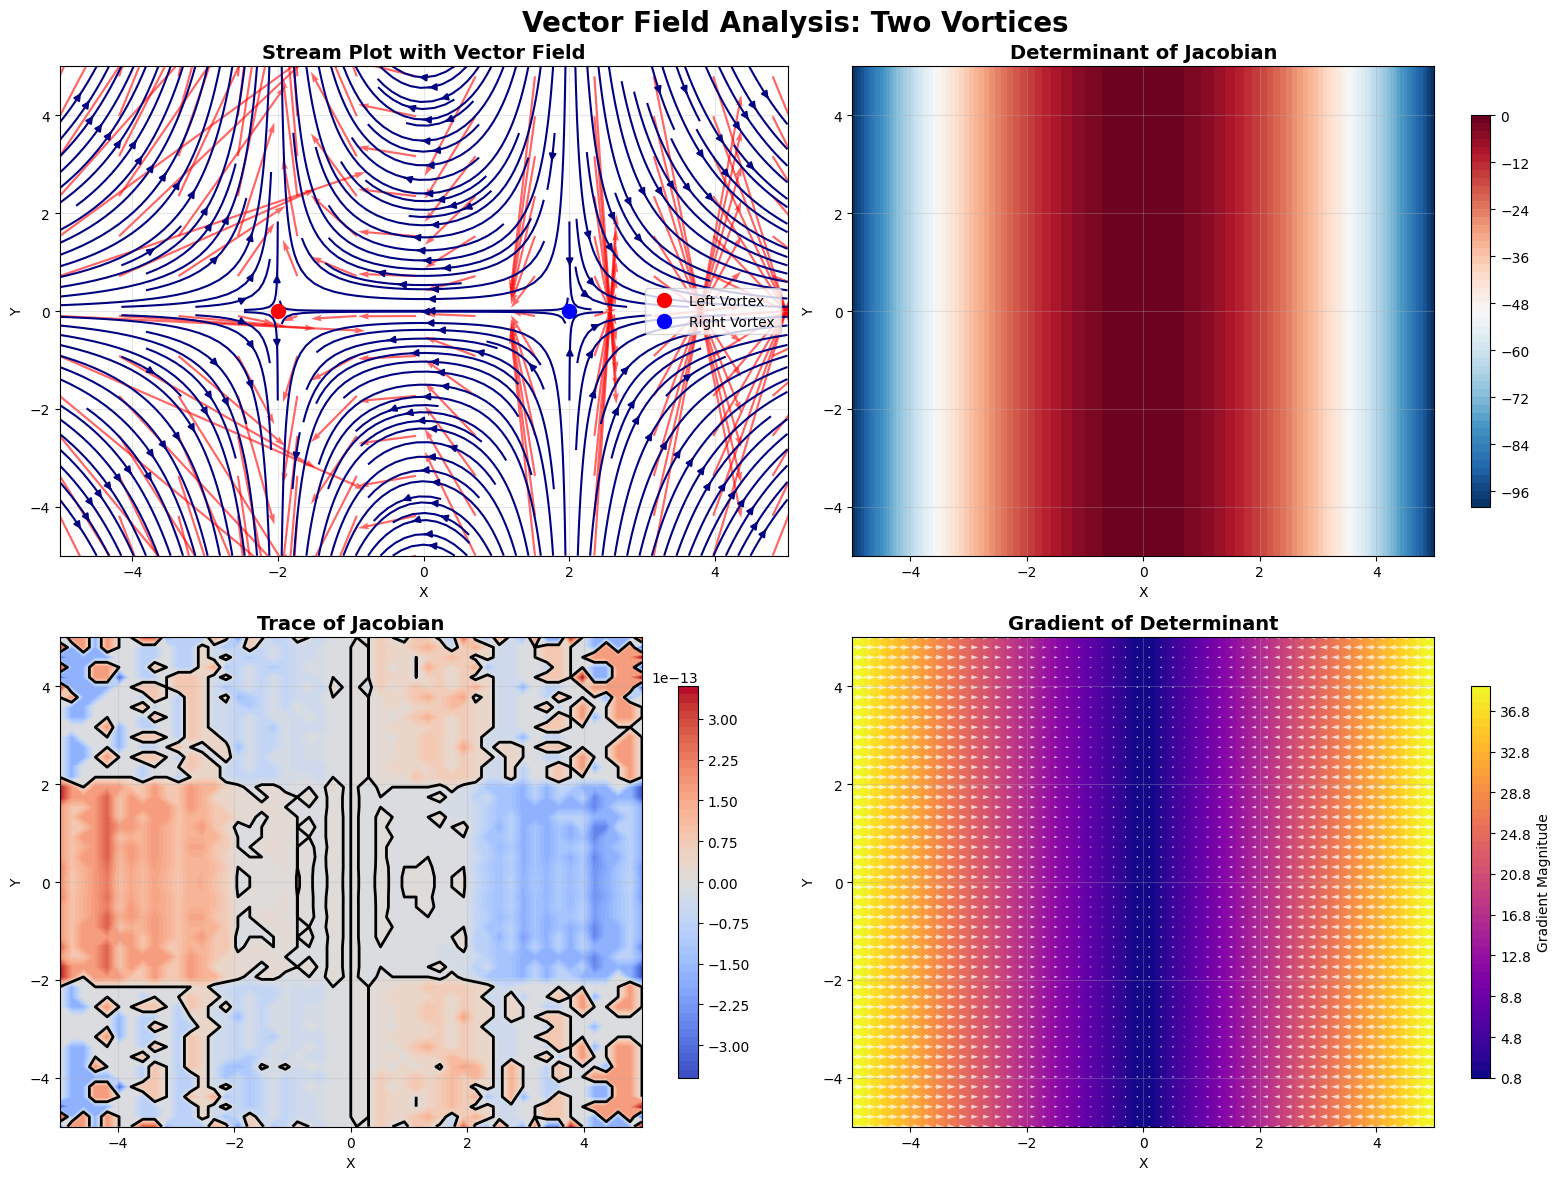



Simulating Mode 2: Square with random offset
determinants [-3.38444047 -2.97957701 -2.39555953 -2.80042299]
tracking_angle 3.8315056070053597 target angle:  1.5707963267948966

Jacobian       [[ 1.70000000e+00 -1.45028736e-16]
 [ 8.00000000e-01 -1.70000000e+00]]
Jacobian Norm  2.533771891863985
Condition Num  1.5941660677252032
free ratio     0.012516910304614215
eigenvalues    [ 1.7 -1.7]
eigenvectors   [0.97341717 0.22903933] [0. 1.]
Actual_flow    [-3.2325  0.68  ]
norm_flow      [-0.97858189  0.20585791]
critical point [-1.90147059 -1.29480969]
centroid       [ 0.85 -0.4 ]
['Primary eigv ', array([0., 1.])]
correction     [-0.96250399  0.27126753]
correct ortho  [-0.96250399  0.        ]
direction      [-0.48125199  1.        ]

verbose step
Step 0: det(J) = -2.8900, centroid = [ 0.85 -0.4 ]
determinants [-3.41683081 -2.42952056 -2.2979042  -3.28521445]
tracking_angle 3.4923992149737906 target angle:  1.5707963267948966

Jacobian       [[ 1.69037496e+00 -2.59709570e-16]
 [ 7.8000

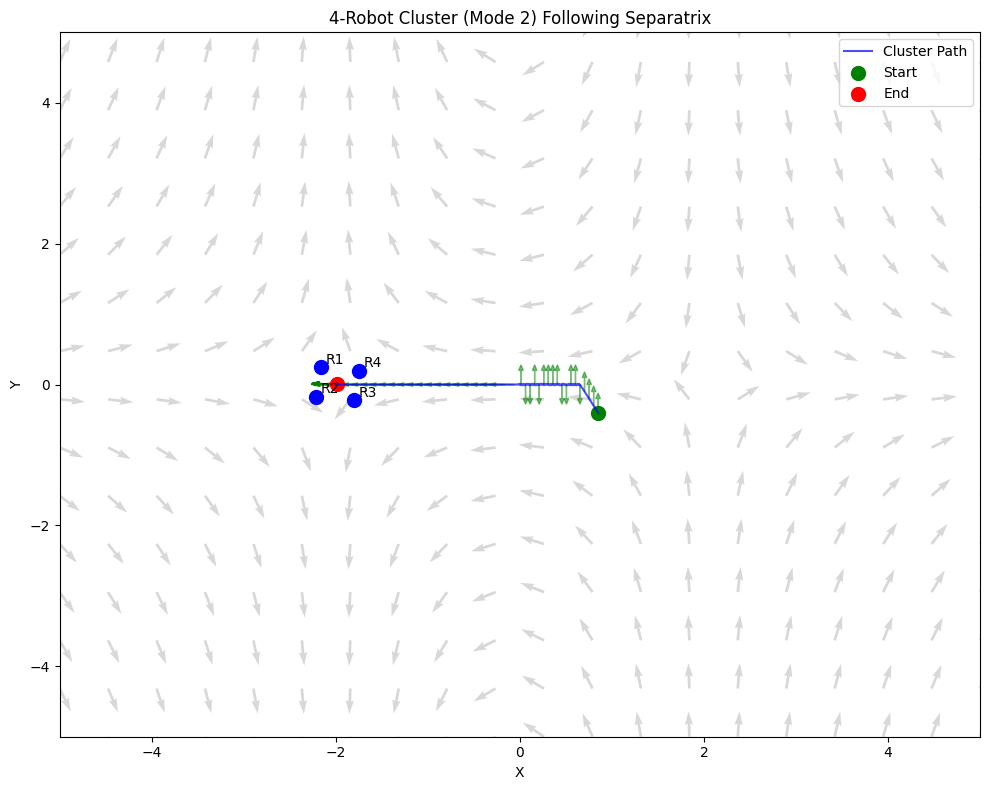

Final formation angle: 127.9 degrees


In [6]:

if __name__ == "__main__":
    # Visualize the vector field
    print("Creating comprehensive field visualization...")
    fig_field = create_comprehensive_visualization(resolution=50)
    plt.show()

    # Test different initialization modes
    modes_to_test = [
        #(1, "Square with manual offset"),
        (2, "Square with random offset"),
        #(3, "Triangle + center with random offset")
    ]

    for mode, description in modes_to_test:
        print(f"\n\nSimulating Mode {mode}: {description}")
        print("="*50)
        
        centroid_hist, eigvec_hist, robots = simulate_separatrix_following(
            init_mode=mode,
            n_steps=700,
            step_size=0.01,
            rotation_rate=0.15,  # Choose 0.15 for mode 2
            correction_weight=0.5,      #Choose 0.5 for mode 3.
            manual_offset= 0,#-5*np.pi/4,  # Choose 0 for for mode 2
            verbose=True
        )
        
        fig = visualize_results(centroid_hist, eigvec_hist, robots)
        plt.show()
        
        if robots.rotation_enabled:
            print(f"Final formation angle: {robots.formation_angle * 180 / np.pi:.1f} degrees")

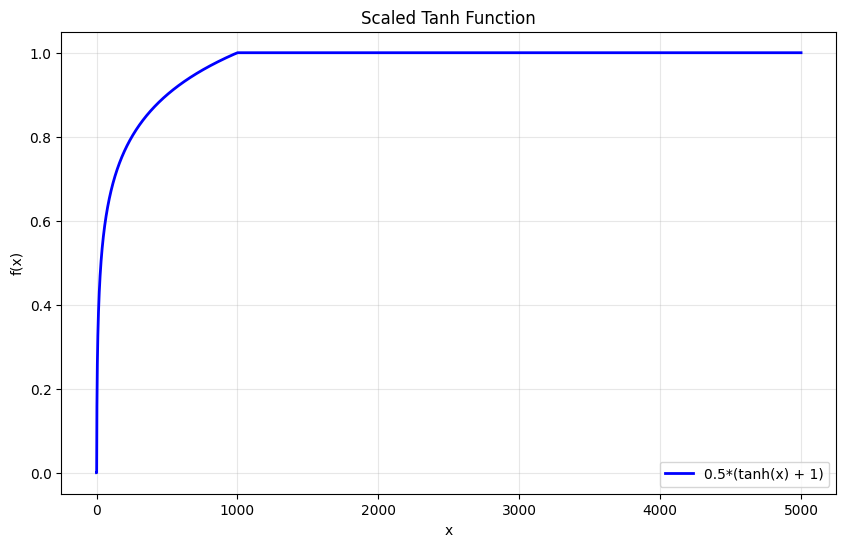

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(0, 5_000, 10_000)

# Calculate scaled tanh
#y =  (np.tanh(x) )
y = np.clip((np.log10(x) - 0) / (3 - 0), 0, 1)
# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='0.5*(tanh(x) + 1)')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Scaled Tanh Function')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()